In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from os import listdir
from os.path import isfile, join
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
os.chdir(module_path)
from src.utils import analysis_utils as au
import re
from tqdm import tqdm
import json 

In [2]:
print(sys.path)

['/workspace/DyLLM/ADALaS/src/analysis', '/opt/conda/lib/python39.zip', '/opt/conda/lib/python3.9', '/opt/conda/lib/python3.9/lib-dynload', '', '/opt/conda/lib/python3.9/site-packages', '/workspace/DyLLM/ADALaS']


In [3]:
# Extract all the datasets into a dictionary with the key as the name
data_path = "results/opt-iml-1.3b/alpaca/full_prop_22-08_03-45-10/checkpoint-1138/hidden_states"
regex = "(.*)_test_hidden_state_np.npy"
dirs = [f for f in listdir(data_path)]
print(dirs)
files_groups = [listdir(os.path.join(data_path,dir)) for dir in dirs]
files = []
for i in range(len(files_groups)):
    for f in files_groups[i]:
        if "hidden_state" in f:
            files.append(f)
print(files)
datasets = {}
for i in range(len(files)):
    configName = re.search(regex, files[i]).group(1)
    datasets[configName] = os.path.join(dirs[i],files[i])
    # datasets[configName] = np.load(join(data_path, f))

['LS4_08-30-2024_22-58', 'R8_08-30-2024_23-10', 'LS8_08-30-2024_22-56', 'R20_1_08-30-2024_23-15', 'LS16_08-30-2024_22-50', 'R8_1_08-30-2024_23-24', 'R16_1_08-30-2024_23-18', 'R4_1_08-30-2024_23-26', 'R20_08-30-2024_23-01', 'R4_08-30-2024_23-12', 'R16_08-30-2024_23-04', 'LS20_08-30-2024_22-47', 'LS12_08-30-2024_22-53', 'R12_1_08-30-2024_23-21', 'full_prop_08-30-2024_22-44', 'R12_08-30-2024_23-07']
['LS4_test_hidden_state_np.npy', 'R8_test_hidden_state_np.npy', 'LS8_test_hidden_state_np.npy', 'RP20_test_hidden_state_np.npy', 'LS16_test_hidden_state_np.npy', 'RP8_test_hidden_state_np.npy', 'RP16_test_hidden_state_np.npy', 'RP4_test_hidden_state_np.npy', 'R20_test_hidden_state_np.npy', 'R4_test_hidden_state_np.npy', 'R16_test_hidden_state_np.npy', 'LS20_test_hidden_state_np.npy', 'LS12_test_hidden_state_np.npy', 'RP12_test_hidden_state_np.npy', 'FM_test_hidden_state_np.npy', 'R12_test_hidden_state_np.npy']


In [4]:
print(datasets.keys())
print(datasets.values())

dict_keys(['LS4', 'R8', 'LS8', 'RP20', 'LS16', 'RP8', 'RP16', 'RP4', 'R20', 'R4', 'R16', 'LS20', 'LS12', 'RP12', 'FM', 'R12'])
dict_values(['LS4_08-30-2024_22-58/LS4_test_hidden_state_np.npy', 'R8_08-30-2024_23-10/R8_test_hidden_state_np.npy', 'LS8_08-30-2024_22-56/LS8_test_hidden_state_np.npy', 'R20_1_08-30-2024_23-15/RP20_test_hidden_state_np.npy', 'LS16_08-30-2024_22-50/LS16_test_hidden_state_np.npy', 'R8_1_08-30-2024_23-24/RP8_test_hidden_state_np.npy', 'R16_1_08-30-2024_23-18/RP16_test_hidden_state_np.npy', 'R4_1_08-30-2024_23-26/RP4_test_hidden_state_np.npy', 'R20_08-30-2024_23-01/R20_test_hidden_state_np.npy', 'R4_08-30-2024_23-12/R4_test_hidden_state_np.npy', 'R16_08-30-2024_23-04/R16_test_hidden_state_np.npy', 'LS20_08-30-2024_22-47/LS20_test_hidden_state_np.npy', 'LS12_08-30-2024_22-53/LS12_test_hidden_state_np.npy', 'R12_1_08-30-2024_23-21/RP12_test_hidden_state_np.npy', 'full_prop_08-30-2024_22-44/FM_test_hidden_state_np.npy', 'R12_08-30-2024_23-07/R12_test_hidden_state_np.

In [5]:
full_model_hidden_states = np.load(join(data_path, datasets["FM"]))
datasets.pop("FM")

'full_prop_08-30-2024_22-44/FM_test_hidden_state_np.npy'

In [6]:
layer_wise_similarities = {}
layer_to_final_similarities = {}

In [7]:
full_model_hidden_states.shape

(25, 57882, 2048)

In [8]:
# Compute the cosine similarities for the layer skipping approach
num_layers = full_model_hidden_states.shape[0]
num_tokens = full_model_hidden_states.shape[1]
for configName, filepath in tqdm(datasets.items()):
    print(configName)
    skipping_model_hidden_states =  np.load(join(data_path, filepath))
    layer_wise_cosine_similarities = np.empty(shape=(24,skipping_model_hidden_states.shape[1]))
    layer_to_final_cosine_similarities = np.empty(shape=(24,skipping_model_hidden_states.shape[1]))
    for i in range(1, num_layers):
        layer_wise_cosine_similarities[i-1] = au.cosine_similarity(full_model_hidden_states[i], skipping_model_hidden_states[i])
        layer_to_final_cosine_similarities[i-1] = au.cosine_similarity(full_model_hidden_states[-1], skipping_model_hidden_states[i])
    layer_wise_similarities[configName] = layer_wise_cosine_similarities
    layer_to_final_similarities[configName] = layer_to_final_cosine_similarities

  0%|                                                                                            | 0/15 [00:00<?, ?it/s]

LS4


  7%|█████▌                                                                             | 1/15 [03:36<50:27, 216.26s/it]

R8


/opt/conda/lib/python3.9/site-packages/numpy/linalg/linalg.py:2583: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))
 13%|███████████                                                                        | 2/15 [06:53<44:24, 204.97s/it]

...

 87%|███████████████████████████████████████████████████████████████████████           | 13/15 [43:52<06:42, 201.22s/it]

RP12


 93%|████████████████████████████████████████████████████████████████████████████▌     | 14/15 [47:12<03:20, 200.98s/it]

R12


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [50:27<00:00, 201.84s/it]


In [9]:
# Compute the cosine similarities for the early exitting approach
for ee_layer in tqdm([4,8,12,16,20]):
    configName = f"B{ee_layer}" # Stands for execute Bottom X layers
    early_exitting_hidden_states = np.append(full_model_hidden_states[:ee_layer], [full_model_hidden_states[ee_layer]] * (num_layers - ee_layer), axis=0) # Repeat the last hidden state before EE
    layer_wise_cosine_similarities = np.empty(shape=(24,skipping_model_hidden_states.shape[1]))
    layer_to_final_cosine_similarities = np.empty(shape=(24,skipping_model_hidden_states.shape[1]))
    for i in range(1, num_layers):
        layer_wise_cosine_similarities[i-1] = au.cosine_similarity(full_model_hidden_states[i], early_exitting_hidden_states[i])
        layer_to_final_cosine_similarities[i-1] = au.cosine_similarity(full_model_hidden_states[-1], early_exitting_hidden_states[i])
    layer_wise_similarities[configName] = layer_wise_cosine_similarities
    layer_to_final_similarities[configName] = layer_to_final_cosine_similarities
    

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [16:55<00:00, 203.11s/it]


In [10]:
print(layer_wise_similarities.keys())

dict_keys(['LS4', 'R8', 'LS8', 'RP20', 'LS16', 'RP8', 'RP16', 'RP4', 'R20', 'R4', 'R16', 'LS20', 'LS12', 'RP12', 'R12', 'B4', 'B8', 'B12', 'B16', 'B20'])


In [11]:
outfile_1 = 'layer_wise_similarities.npz'
np.savez(outfile_1, **layer_wise_similarities)
outfile_2 = 'layer_to_final_similarities.npz'
np.savez(outfile_2, **layer_to_final_similarities)

In [8]:
# Save to json file
with open('layer_wise_similarities_T.json', 'w') as fout:
    json.dump(str(layer_wise_similarities), fout)

with open('layer_to_final_similarities_T.json', 'w') as fout:
    json.dump(str(layer_to_final_similarities), fout)

In [8]:
# Load from json file
with open('layer_wise_similarities.json', 'r') as fin:
    layer_wise_similarities = eval(json.load(fin))

with open('layer_to_final_similarities.json', 'r') as fin:
    layer_to_final_similarities = eval(json.load(fin))

In [14]:
B_index = [i for i in range (1,24)]
LS_index = [4,8,12,16,20]
B_values = [layer_wise_similarities[f"B{i}"][-1] for i in B_index] 
LS_values = [layer_wise_similarities[f"LS{i}"][-1] for i in LS_index] 

Text(0, 0.5, 'Cosine Similarity')

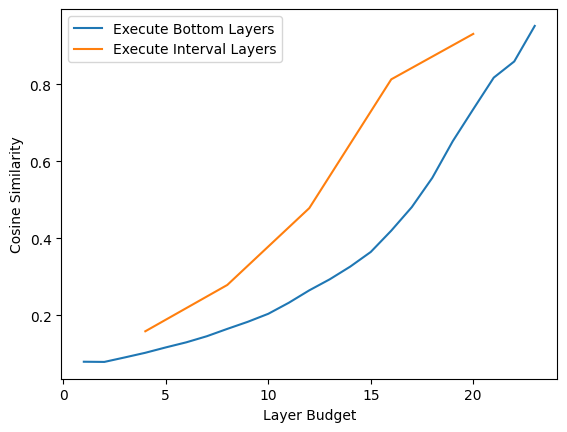

In [18]:
plt.figure()
plt.plot(B_index,B_values,label="Execute Bottom Layers")
plt.plot(LS_index,LS_values, label="Execute Interval Layers")
plt.legend()
plt.xlabel("Layer Budget")
plt.ylabel("Cosine Similarity")


Text(0.5, 1.0, 'Layer-wise cosine similarities with full model')

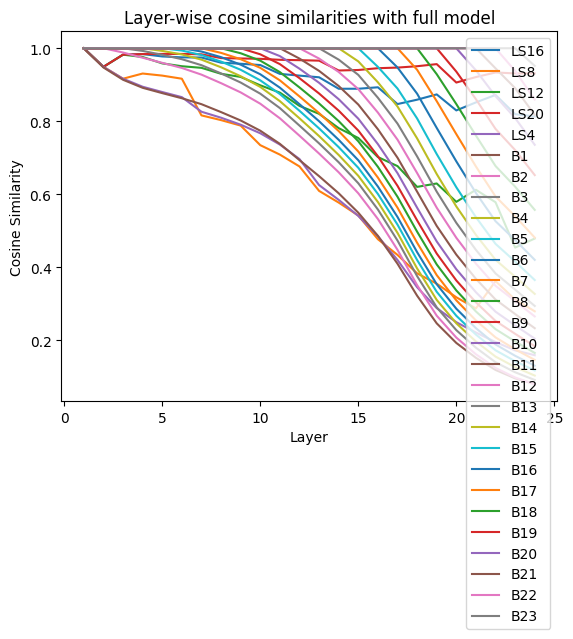

In [9]:
# Plot all the layer-wise cosine similarities
plt.figure()
for configName, similarities in layer_wise_similarities.items():
    plt.plot(range(1, num_layers), similarities, label=configName)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.title("Layer-wise cosine similarities with full model")

Text(0.5, 1.0, 'Layer to final cosine similarities with full model')

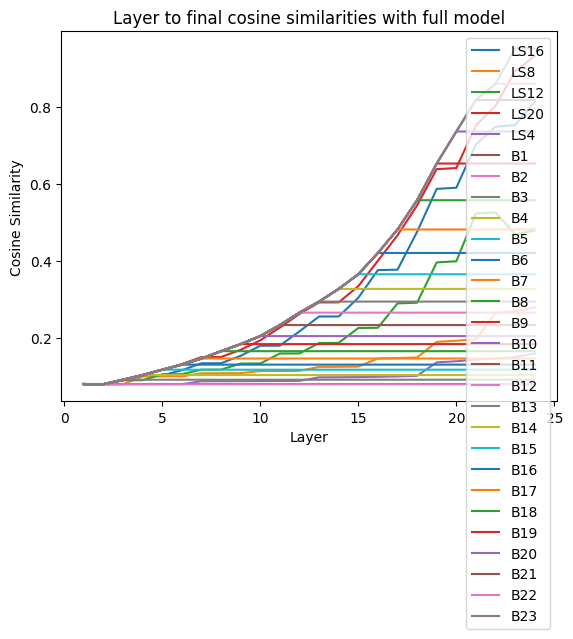

In [10]:
# Plot all the layer to final cosine similarities
plt.figure()
for configName, similarities in layer_to_final_similarities.items():
    plt.plot(range(1, num_layers), similarities, label=configName)
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.title("Layer to final cosine similarities with full model")